<a href="https://colab.research.google.com/github/GeorgeT27/Generative-model-DYI/blob/main/Conditional_Flow_Matching_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import math
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Compose, Normalize
from torch.utils.data import DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import StepLR
import torch.distributions as distributions
from tqdm import tqdm
import pandas as pd
from copy import deepcopy
from morphomnist import io
import os 

In [2]:
df=pd.read_csv('/workspace/Generative-model-DYI/data/Morpho_MNIST/measuring_intensity/train-morpho.csv')
df['intensity'].mean(), df['intensity'].std()

(np.float64(158.01583863316668), np.float64(48.379700978031266))

# Create Morpho Dataset class

In [3]:
class MorphoMNISTDataset(torch.utils.data.Dataset):
    """Custom dataset class for Morpho-MNIST data"""

    def __init__(self, root, train=True, download=False, transform=None,
                 load_morphometrics=False, load_perturbations=False, variant='global'):
        self.root = root
        self.train = train
        self.transform = transform
        self.load_morphometrics = load_morphometrics
        self.load_perturbations = load_perturbations
        self.variant = variant

        # Updated path structure to match your data organization
        self.morpho_dir = os.path.join(root, f'Morpho_MNIST/{variant}')
        if not os.path.exists(self.morpho_dir):
            os.makedirs(self.morpho_dir)
            print(f"Created directory: {self.morpho_dir}")

        if download:
            self.download_data()

        # Load data
        try:
            self.data, self.targets, self.morphometrics, self.perturbations = self._load_data()
            print(f"✅ Successfully loaded {len(self.data)} samples from {self.morpho_dir}")
        except FileNotFoundError as e:
            print(f"❌ Data files not found: {e}")
            print("Please download the data manually (see instructions above)")
            raise

    def download_data(self):
        """Download Morpho-MNIST data if not exists"""
        print("📥 Manual download required:")
        print("1. Go to: https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL")
        print(f"2. Download: {self.variant}.tar.gz")
        print(f"3. Extract to: {self.morpho_dir}")
        print("\nAvailable variants: plain, global, local, thin, thic, swel, frac")

    def _load_data(self):
        """Load Morpho-MNIST data files"""
        prefix = 'train' if self.train else 't10k'

        # Load images
        images_file = os.path.join(self.morpho_dir, f'{prefix}-images-idx3-ubyte.gz')
        if os.path.exists(images_file):
            print(f"Loading images from: {images_file}")
            images = io.load_idx(images_file)
        else:
            raise FileNotFoundError(f"Images file not found: {images_file}")

        # Load labels
        labels_file = os.path.join(self.morpho_dir, f'{prefix}-labels-idx1-ubyte.gz')
        if os.path.exists(labels_file):
            print(f"Loading labels from: {labels_file}")
            labels = io.load_idx(labels_file)
        else:
            raise FileNotFoundError(f"Labels file not found: {labels_file}")

        # Load morphometrics (CSV file) - only if requested
        morphometrics = None
        if self.load_morphometrics:
            morpho_file = os.path.join(self.morpho_dir, f'{prefix}-morpho.csv')
            if os.path.exists(morpho_file):
                print(f"Loading morphometrics from: {morpho_file}")
                morphometrics = pd.read_csv(morpho_file)
                print(f"Morphometric features: {list(morphometrics.columns)}")
            else:
                print(f"Warning: Morphometrics file not found: {morpho_file}")

        # Load perturbation labels (if available) - only if requested
        perturbations = None
        if self.load_perturbations:
            pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte.gz')
            if os.path.exists(pert_file):
                print(f"Loading perturbations from: {pert_file}")
                perturbations = io.load_idx(pert_file)
            else:
                print(f"Warning: Perturbation file not found: {pert_file}")

        return images, labels, morphometrics, perturbations

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        target = self.targets[idx]

        # Convert to tensor and normalize to [0, 1]
        image = torch.from_numpy(image.copy()).float() / 255.0
        image = image.unsqueeze(0)  # Add channel dimension

        if self.transform:
            image = self.transform(image)

        sample = {
            'image': image,
            'target': target,
        }

        if self.morphometrics is not None:
            morpho_data = self.morphometrics.iloc[idx]
            sample['morphometrics'] = {
                'thickness': morpho_data['thickness'],
                'intensity': morpho_data['intensity']
            }

        if self.perturbations is not None:
            sample['perturbation'] = self.perturbations[idx]

        return sample

In [4]:
# Option 1: Basic usage (no morphometrics/perturbations) - Most memory efficient
dataset = MorphoMNISTDataset(
    root='/workspace/Generative-model-DYI/data',
    train=True,
    download=False,  # Will show download instructions
    transform=None,  # We handle normalization in the custom dataset
    load_morphometrics=True,  # Don't load morphometrics to save memory
    load_perturbations=True,   # Don't load perturbations to save memory
    variant='measuring_intensity'
)


def morpho_collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    targets = torch.tensor([item['target'] for item in batch], dtype=torch.long)  # Fix: ensure LongTensor

    # Extract morphometric features into tensors
    morphometrics = None
    if any('morphometrics' in item for item in batch):
        morpho_data = [item.get('morphometrics', None) for item in batch]
        if morpho_data[0] is not None:  # Check if morphometrics are actually loaded
            morphometrics = {
                'thickness': torch.tensor([m['thickness'] for m in morpho_data], dtype=torch.float32),
                'intensity': torch.tensor([m['intensity'] for m in morpho_data], dtype=torch.float32)
            }

    return images, targets, morphometrics

Loading images from: /workspace/Generative-model-DYI/data/Morpho_MNIST/measuring_intensity/train-images-idx3-ubyte.gz
Loading labels from: /workspace/Generative-model-DYI/data/Morpho_MNIST/measuring_intensity/train-labels-idx1-ubyte.gz
Loading morphometrics from: /workspace/Generative-model-DYI/data/Morpho_MNIST/measuring_intensity/train-morpho.csv
Morphometric features: ['index', 'thickness', 'intensity']
✅ Successfully loaded 60000 samples from /workspace/Generative-model-DYI/data/Morpho_MNIST/measuring_intensity


In [5]:
class RectifiedFlow:
  def euler(self,x_t,v,dt):
    x_t=x_t+v*dt
    return x_t
  def create_flow(self,x_1,t):
    x_0=torch.randn_like(x_1)
    t=t[:,None,None,None]
    x_t=t*x_1+(1-t)*x_0
    return x_t,x_0
  def mse_loss(self,x_1,x_0,v):
    loss=F.mse_loss(x_1-x_0,v)
    return loss

In [6]:
# Deeper UNet for MNIST 28*28 with thickness conditioning
class DownLayer(nn.Module):
    """MiniUnet的下采样层 Resnet
    """

    def __init__(self,
                 in_channels,
                 out_channels,
                 time_emb_dim=16,
                 downsample=False):
        super(DownLayer, self).__init__()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU()

        # 线性层，用于时间编码换通道 [B, dim] -> [B, in_channels]
        self.fc = nn.Linear(time_emb_dim, in_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None

        # 降采样
        self.downsample = downsample
        if downsample:
            self.pool = nn.MaxPool2d(2)

        self.in_channels = in_channels

    def forward(self, x, temb):
        # x: [B, C, H, W]
        res = x
        x += self.fc(temb)[:, :, None, None]  # [B, in_channels, 1, 1]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)

        if self.shortcut is not None:
            res = self.shortcut(res)

        x = x + res

        if self.downsample:
            x = self.pool(x)

        return x


class UpLayer(nn.Module):
    """MiniUnet的上采样层
    """

    def __init__(self,
                 in_channels,
                 out_channels,
                 time_emb_dim=16,
                 upsample=False):
        super(UpLayer, self).__init__()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU()

        # 线性层，用于时间编码换通道
        self.fc = nn.Linear(time_emb_dim, in_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None

        self.upsample = upsample
        if upsample:
            self.upsample = nn.Upsample(scale_factor=2)

    def forward(self, x, temb):
        # 上采样
        if self.upsample:
            x = self.upsample(x)
        res = x

        x += self.fc(temb)[:, :, None, None]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)

        if self.shortcut is not None:
            res = self.shortcut(res)
        x = x + res

        return x


class MiddleLayer(nn.Module):
    """MiniUnet的中间层
    """

    def __init__(self, in_channels, out_channels, time_emb_dim=16):
        super(MiddleLayer, self).__init__()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU()

        # 线性层，用于时间编码换通道
        self.fc = nn.Linear(time_emb_dim, in_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None

    def forward(self, x, temb):
        res = x

        x += self.fc(temb)[:, :, None, None]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)

        if self.shortcut is not None:
            x = self.shortcut(x)
        x = x + res

        return x


class DeeperUnet(nn.Module):
    """Fixed Deeper UNet for MNIST with thickness conditioning
    """

    def __init__(self, base_channels=32, time_emb_dim=None):
        super(DeeperUnet, self).__init__()

        if time_emb_dim is None:
            time_emb_dim = base_channels

        self.time_emb_dim = time_emb_dim
        self.base_channels = base_channels

        self.conv_in = nn.Conv2d(1, base_channels, kernel_size=3, padding=1)

        # Down blocks - Fixed architecture
        # Level 1: 28x28 -> 14x14
        self.down1 = nn.ModuleList([
            DownLayer(base_channels,
                      base_channels * 2,
                      time_emb_dim=time_emb_dim,
                      downsample=False),
            DownLayer(base_channels * 2,
                      base_channels * 2,
                      time_emb_dim=time_emb_dim)
        ])
        self.maxpool1 = nn.MaxPool2d(2)  # 28x28 -> 14x14

        # Level 2: 14x14 -> 7x7
        self.down2 = nn.ModuleList([
            DownLayer(base_channels * 2,
                      base_channels * 4,
                      time_emb_dim=time_emb_dim,
                      downsample=False),
            DownLayer(base_channels * 4,
                      base_channels * 4,
                      time_emb_dim=time_emb_dim)
        ])
        self.maxpool2 = nn.MaxPool2d(2)  # 14x14 -> 7x7

        # Level 3: 7x7 -> 3x3 (using stride 2 for odd dimensions)
        self.down3 = nn.ModuleList([
            DownLayer(base_channels * 4,
                      base_channels * 8,
                      time_emb_dim=time_emb_dim,
                      downsample=False),
            DownLayer(base_channels * 8,
                      base_channels * 8,
                      time_emb_dim=time_emb_dim)
        ])
        # Use conv with stride 2 - 7x7 -> 3x3 (more natural for odd dimensions)
        self.maxpool3 = nn.Conv2d(base_channels * 8, base_channels * 8, 
                                  kernel_size=3, stride=2, padding=0)  # 7x7 -> 3x3

        # Middle layer
        self.middle = MiddleLayer(base_channels * 8,
                                  base_channels * 8,
                                  time_emb_dim=time_emb_dim)

        # Up blocks - Fixed with proper dimensions
        # Level 1: 3x3 -> 7x7 (to match x3)
        self.upsample1 = nn.ConvTranspose2d(base_channels * 8, base_channels * 8, 
                                           kernel_size=3, stride=2, padding=0, output_padding=0)  # 3x3 -> 7x7
        
        self.up1 = nn.ModuleList([
            UpLayer(
                base_channels * 16,  # concat from down3: 8*base + 8*base
                base_channels * 4,
                time_emb_dim=time_emb_dim,
                upsample=False),
            UpLayer(base_channels * 4,
                    base_channels * 4,
                    time_emb_dim=time_emb_dim)
        ])
        
        # Level 2: 7x7 -> 14x14 (to match x2)
        self.upsample2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 4, 
                                           kernel_size=2, stride=2)  # 7x7 -> 14x14
        self.up2 = nn.ModuleList([
            UpLayer(base_channels * 8,  # concat from down2: 4*base + 4*base
                    base_channels * 2,
                    time_emb_dim=time_emb_dim,
                    upsample=False),
            UpLayer(base_channels * 2,
                    base_channels * 2,
                    time_emb_dim=time_emb_dim)
        ])
        
        # Level 3: 14x14 -> 28x28 (to match x1)
        self.upsample3 = nn.ConvTranspose2d(base_channels * 2, base_channels * 2, 
                                           kernel_size=2, stride=2)  # 14x14 -> 28x28
        self.up3 = nn.ModuleList([
            UpLayer(base_channels * 4,  # concat from down1: 2*base + 2*base
                    base_channels,
                    time_emb_dim=time_emb_dim,
                    upsample=False),
            UpLayer(base_channels,
                    base_channels,
                    time_emb_dim=time_emb_dim)
        ])

        self.conv_out = nn.Conv2d(base_channels, 1, kernel_size=1, padding=0)

    def time_emb(self, t, dim):
        """对时间进行正弦函数的编码"""
        # 把t映射到[0, 1000]
        t = t * 1000
        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(t.device)
        sin_emb = torch.sin(t[:, None] / freqs)
        cos_emb = torch.cos(t[:, None] / freqs)

        return torch.cat([sin_emb, cos_emb], dim=-1)

    def label_emb(self, y, dim):
        """对类别标签进行编码"""
        y = y * 1000
        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(y.device)
        sin_emb = torch.sin(y[:, None] / freqs)
        cos_emb = torch.cos(y[:, None] / freqs)

        return torch.cat([sin_emb, cos_emb], dim=-1)

    def thickness_emb(self, thickness, dim):
        """对thickness进行编码 - Balanced scaling"""
        # Normalize thickness to reasonable range first
        thickness_norm = torch.clamp(thickness, 0.1, 5.0)  # Clamp to reasonable range
        thickness_scaled = thickness_norm  # Remove the *200 scaling - keep raw normalized values

        freqs = torch.pow(6, torch.linspace(0, 1, dim // 2)).to(thickness.device)
        sin_emb = torch.sin(thickness_scaled[:, None] / freqs)
        cos_emb = torch.cos(thickness_scaled[:, None] / freqs)
        return torch.cat([sin_emb, cos_emb], dim=-1)

    def intensity_emb(self, intensity, dim):
        """对intensity进行编码 - Balanced scaling"""
        # Normalize intensity to reasonable range first
        intensity_norm = torch.clamp(intensity, 50.0, 250.0)  # Updated for mean=150, std=50
        intensity_scaled = (intensity_norm - 49.0) / 200.0 * 5.0  # Scale to [0, 5] to match thickness range

        freqs = torch.pow(6, torch.linspace(0, 1, dim // 2)).to(intensity.device)
        sin_emb = torch.sin(intensity_scaled[:, None] / freqs)
        cos_emb = torch.cos(intensity_scaled[:, None] / freqs)
        return torch.cat([sin_emb, cos_emb], dim=-1)
    
    def forward(self, x, t, y=None, thickness=None, intensity=None):
        """前向传播函数 - Fixed embedding handling"""
        # x:(B, C, H, W) - Input should be 28x28
        x = self.conv_in(x)  # 28x28 -> 28x28 with base_channels
        
        # Create separate embeddings and concatenate them
        temb = self.time_emb(t, self.base_channels)
        
        # Handle label conditioning
        if y is not None:
            yemb = self.label_emb(y, self.base_channels)
            yemb[y == -1] = 0.0
            temb = temb + yemb  # Add instead of concatenate to maintain dimension
        
        # Handle thickness conditioning
        if thickness is not None:
            thickness_emb = self.thickness_emb(thickness, self.base_channels)
            thickness_emb[thickness == -1] = 0.0
            temb = temb + thickness_emb  # Add instead of concatenate
        
        # Handle intensity conditioning
        if intensity is not None:
            intensity_emb = self.intensity_emb(intensity, self.base_channels)
            intensity_emb[intensity == -1] = 0.0
            temb = temb + intensity_emb  # Add instead of concatenate
        
        # Down path with skip connections
        for layer in self.down1:
            x = layer(x, temb)
        x1 = x  # Skip connection 1: [B, 64, 28, 28]
        x = self.maxpool1(x)  # [B, 64, 14, 14]
        
        for layer in self.down2:
            x = layer(x, temb)
        x2 = x  # Skip connection 2: [B, 128, 14, 14]
        x = self.maxpool2(x)  # [B, 128, 7, 7]
        
        for layer in self.down3:
            x = layer(x, temb)
        x3 = x  # Skip connection 3: [B, 256, 7, 7]
        x = self.maxpool3(x)  # [B, 256, 3, 3]

        # Middle layer
        x = self.middle(x, temb)  # [B, 256, 3, 3]

        # Up path with skip connections
        x = self.upsample1(x)  # [B, 256, 7, 7] - Now matches x3 exactly
        x = torch.cat([x, x3], dim=1)  # [B, 512, 7, 7]
        for layer in self.up1:
            x = layer(x, temb)  # [B, 128, 7, 7]
            
        x = self.upsample2(x)  # [B, 128, 14, 14]
        x = torch.cat([x, x2], dim=1)  # [B, 256, 14, 14]
        for layer in self.up2:
            x = layer(x, temb)  # [B, 64, 14, 14]
            
        x = self.upsample3(x)  # [B, 64, 28, 28]
        x = torch.cat([x, x1], dim=1)  # [B, 128, 28, 28]
        for layer in self.up3:
            x = layer(x, temb)  # [B, 32, 28, 28]

        x = self.conv_out(x)  # [B, 1, 28, 28]
        return x

In [7]:
class EMA(nn.Module):
    def __init__(self, model, decay=0.9999, device=None):
        super(EMA, self).__init__()
        # make a copy of the model for accumulating moving average of weights
        self.module = deepcopy(model)
        self.module.eval()
        self.decay = decay
        self.device = device  # perform EMA on different device from model if set
        if self.device is not None:
            self.module.to(device=self.device)

    def _update(self, model, update_fn):
        with torch.no_grad():
            for ema_v, model_v in zip(self.module.state_dict().values(),
                                      model.state_dict().values()):
                if self.device is not None:
                    model_v = model_v.to(device=self.device)
                ema_v.copy_(update_fn(ema_v, model_v))

    def update(self, model):
        self._update(
            model,
            update_fn=lambda e, m: self.decay * e + (1.0 - self.decay) * m
        )

    def set(self, model):
        self._update(
            model,
            update_fn=lambda e, m: m
        )

In [8]:
# Improved training configuration
epochs= 100  # More epochs
batch_size= 128  # Larger batch size for more stable gradients
lr= 4e-4  # Slightly higher learning rate initially
weight_decay= 1e-4  # Less regularization
ema_decay= 0.9999
grad_clip= 1.0
lr_schedule= True
step_size= 40  # Reduce LR later
gamma= 0.5 # More gradual LR reduction
lr_adjust_epoch= 25 # 学习率调整的epoch，降为原有的10%
batch_print_interval= 100 # 打印间隔，以batch为单位
device= 'cuda' # cuda、cpu、mps(only macbook)
checkpoint_save_interval= 10 # 模型保存间隔，以epoch为单位

In [9]:
import pandas as pd  # Add this import for morpho dataset

# Use MorphoMNIST dataset instead of regular MNIST
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=morpho_collate_fn)

# IMPORTANT: Recreate the model with fixed architecture
print("Creating new model with fixed architecture...")
model = DeeperUnet(base_channels=32).to(device)  # Use fixed deeper model
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
schedular = StepLR(optimizer, step_size=step_size, gamma=gamma)
rf = RectifiedFlow()
ema = EMA(model, decay=0.999, device=device)

print("Starting training with thickness conditioning...")
for epoch in range(epochs):
    pbar = tqdm(dataloader, desc=f'Epoch {epoch}')
    total_loss = 0
    num_batches = 0
    
    for batch_data in pbar:
        images, labels, morphometrics = batch_data
        x_1 = images
        y = labels
        
        # Extract thickness if available
        thickness = None
        if morphometrics is not None:
            thickness = morphometrics['thickness']
            intensity = morphometrics['intensity']
            # Debug: Check thickness values
            if epoch == 0 and num_batches == 0:
                print(f"Thickness range: {thickness.min():.3f} to {thickness.max():.3f}")
                print(f"Intensity range: {intensity.min():.3f} to {intensity.max():.3f}")
        
        t = torch.rand(x_1.size(0))
        x_t, x_0 = rf.create_flow(x_1, t)
        x_t = x_t.to(device)
        x_0 = x_0.to(device)
        x_1 = x_1.to(device)
        t = t.to(device)
        y = y.to(device)        
        thickness = thickness.to(device)
        intensity = intensity.to(device)

        optimizer.zero_grad()
        
        # We train with both conditional and unconditional model
        x_t = torch.cat([x_t, x_t.clone()], dim=0)
        x_0 = torch.cat([x_0, x_0.clone()], dim=0)
        x_1 = torch.cat([x_1, x_1.clone()], dim=0)
        t = torch.cat([t, t.clone()], dim=0)
        y = torch.cat([y, -torch.ones_like(y)], dim=0)
        thickness = torch.cat([thickness, -torch.ones_like(thickness)], dim=0)  # -1 for unconditional
        intensity = torch.cat([intensity, -torch.ones_like(intensity)], dim=0)
        
        # Debug: Check tensor shapes before model forward
        if epoch == 0 and num_batches == 0:
            print(f"Input shapes: x_t={x_t.shape}, t={t.shape}, y={y.shape}")
            print(f"Thickness shape: {thickness.shape}, Intensity shape: {intensity.shape}")
            test_emb = model.intensity_emb(intensity[:5], model.base_channels)
            print(f"Intensity embedding shape: {test_emb.shape}")
            print(f"Intensity embedding range: {test_emb.min():.3f} to {test_emb.max():.3f}")
        
        v_pred = model(x_t, t, y, thickness, intensity)
        loss = rf.mse_loss(x_1, x_0, v_pred)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)
        
        total_loss += loss.item()
        num_batches += 1
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'avg_loss': f'{total_loss/num_batches:.4f}'})
        
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Average loss = {total_loss/num_batches:.4f}")
        torch.save({
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'loss': total_loss/num_batches
        }, f"morpho_ckpt_{epoch}.pth")
        print(f"Checkpoint saved: morpho_ckpt_{epoch}.pth")

print("Training completed!")

Creating new model with fixed architecture...
Model parameters: 6,713,409
Starting training with thickness conditioning...
Model parameters: 6,713,409
Starting training with thickness conditioning...


Creating new model with fixed architecture...
Model parameters: 6,713,409
Starting training with thickness conditioning...
Model parameters: 6,713,409
Starting training with thickness conditioning...


Epoch 0:   0%|          | 0/469 [00:00<?, ?it/s]

Creating new model with fixed architecture...
Model parameters: 6,713,409
Starting training with thickness conditioning...
Model parameters: 6,713,409
Starting training with thickness conditioning...


Epoch 0:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 5: Average loss = 0.0587
Checkpoint saved: morpho_ckpt_5.pth


Epoch 10: 100%|██████████| 469/469 [01:06<00:00,  7.06it/s, loss=0.0516, avg_loss=0.0550]



Epoch 10: Average loss = 0.0550
Checkpoint saved: morpho_ckpt_10.pth


Epoch 11:  12%|█▏        | 57/469 [00:08<00:59,  6.90it/s, loss=0.0555, avg_loss=0.0549]



KeyboardInterrupt: 

Generating samples with improved intensity conditioning...
Intensity -> Generated Brightness:
  70 -> 0.0311
  92 -> 0.0264
  115 -> 0.0226
  138 -> 0.0505
  160 -> 0.0550
  182 -> 0.1331
  205 -> 0.0635
  228 -> 0.1159
  250 -> 0.2025
Intensity -> Generated Brightness:
  70 -> 0.0311
  92 -> 0.0264
  115 -> 0.0226
  138 -> 0.0505
  160 -> 0.0550
  182 -> 0.1331
  205 -> 0.0635
  228 -> 0.1159
  250 -> 0.2025


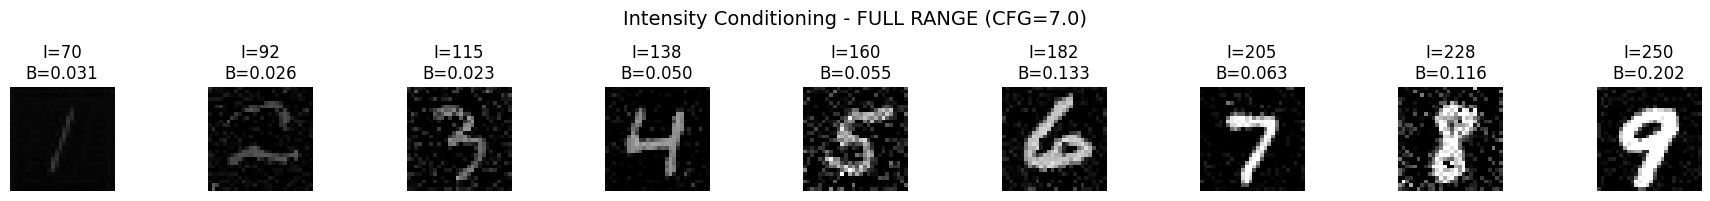

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sample(model, rf, num_samples, cfg_scale, y=None, thickness=None,intensity=None, num_steps=50, device='cuda'):
    """Generate samples using the trained flow matching model with thickness conditioning

    Args:
        model: Trained DeeperUnet model
        rf: RectifiedFlow instance
        num_samples: Number of samples to generate
        cfg_scale: Classifier-free guidance scale
        y: Label conditioning (optional)
        thickness: Thickness conditioning (optional)
        num_steps: Number of integration steps
        device: Device to run on
    """
    if y is not None:
        assert len(y.shape) == 1, 'y must be 1D tensor'
        if y.shape[0] == 1:
            y = y.repeat(num_samples).reshape(num_samples)
        y = y.to(device)
    
    if thickness is not None:
        assert len(thickness.shape) == 1, 'thickness must be 1D tensor'
        if thickness.shape[0] == 1:
            thickness = thickness.repeat(num_samples).reshape(num_samples)
        thickness = thickness.to(device)
    
    if intensity is not None:
        assert len(intensity.shape) == 1, 'intensity must be 1D tensor'
        if intensity.shape[0] == 1:
            intensity = intensity.repeat(num_samples).reshape(num_samples)
        intensity = intensity.to(device)
    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps
        # Start from noise
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Integrate the flow from t=0 to t=1
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)
            v_pred_uncon = model(x_t, t)  # Unconditional
            v_pred_con = model(x_t, t, y, thickness,intensity)  # Conditional with both y and thickness
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def load_ema_model(checkpoint_path, device='cuda'):
    """Properly load EMA model from checkpoint with memory efficiency"""
    # Create the SAME architecture as used in training
    # Based on the error, the saved model has attention=True and num_res_blocks=2
    model=DeeperUnet(base_channels=32).to(device) 
    
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Create EMA wrapper and load the EMA state dict
    ema = EMA(model, decay=0.999, device=device)
    ema.load_state_dict(checkpoint['ema_state_dict'])
    
    return ema.module  # Return the underlying model

def generate_intensity_samples_improved(labels, thickness_vals, intensity_vals, sampling_model, rf):
    """Generate samples with optimal settings for intensity conditioning"""
    print("Generating samples with improved intensity conditioning...")
    
    labels =labels
    thickness_vals = thickness_vals
    intensity_vals = intensity_vals
    
    # Use higher CFG scale for stronger conditioning
    samples = sample(sampling_model, rf, num_samples=9, cfg_scale=7.0,  # Higher CFG!
                    y=labels, thickness=thickness_vals, intensity=intensity_vals, 
                    num_steps=100, device='cuda')
    
    # Calculate and display brightness values
    samples_np = samples.cpu().numpy()
    print("Intensity -> Generated Brightness:")
    for i in range(9):
        brightness = samples_np[i, 0].mean()
        print(f"  {intensity_vals[i]:.0f} -> {brightness:.4f}")
    
    # Visualize with brightness labels
    fig, axes = plt.subplots(1, 9, figsize=(18, 2))
    for i in range(9):
        brightness = samples_np[i, 0].mean()
        axes[i].imshow(samples_np[i, 0], cmap='gray', vmin=0, vmax=1)
        axes[i].set_title(f"I={intensity_vals[i]:.0f}\nB={brightness:.3f}")
        axes[i].axis('off')
    plt.suptitle("Generate morpho-mnist sample", fontsize=14)
    plt.tight_layout()
    plt.show()

# Use the EMA model for sampling (no need to load checkpoint)
sampling_model = load_ema_model('morpho_ckpt_10.pth')
sampling_model.eval()
generate_intensity_samples_improved(
    labels= torch.arange(1,10,1),
    thickness_vals=torch.linspace(1,4,9),
    intensity_vals=torch.linspace(70,250,9),
    sampling_model=sampling_model,
    rf=rf
)

Generating samples with improved intensity conditioning...
Intensity -> Generated Brightness:
  70 -> 0.0191
  92 -> 0.0344
  115 -> 0.0369
  138 -> 0.0466
  160 -> 0.0620
  182 -> 0.0515
  205 -> 0.0536
  228 -> 0.0913
  250 -> 0.1260
Intensity -> Generated Brightness:
  70 -> 0.0191
  92 -> 0.0344
  115 -> 0.0369
  138 -> 0.0466
  160 -> 0.0620
  182 -> 0.0515
  205 -> 0.0536
  228 -> 0.0913
  250 -> 0.1260


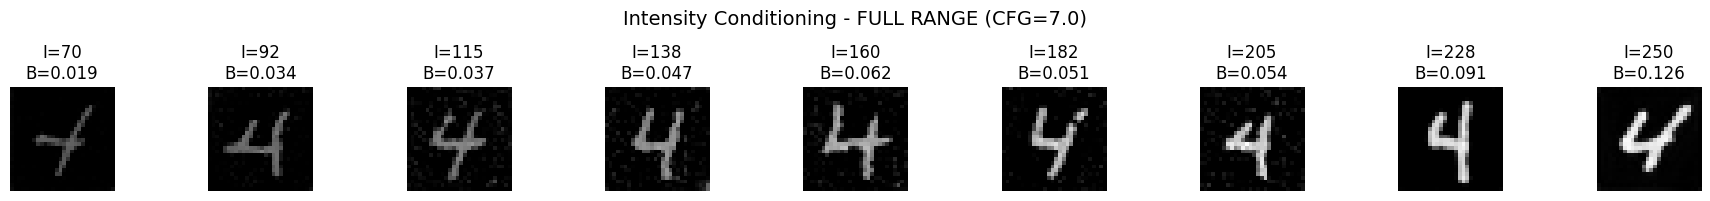

In [51]:
generate_intensity_samples_improved(
    labels= torch.ones(9)*4,
    thickness_vals=torch.ones(9)*2,
    intensity_vals=torch.linspace(70,250,9),
    sampling_model=sampling_model,
    rf=rf
)

Generating samples with improved intensity conditioning...
Intensity -> Generated Brightness:
  200 -> 0.0503
  200 -> 0.0638
  200 -> 0.0653
  200 -> 0.0682
  200 -> 0.0846
  200 -> 0.0878
  200 -> 0.0923
  200 -> 0.0890
  200 -> 0.0921
Intensity -> Generated Brightness:
  200 -> 0.0503
  200 -> 0.0638
  200 -> 0.0653
  200 -> 0.0682
  200 -> 0.0846
  200 -> 0.0878
  200 -> 0.0923
  200 -> 0.0890
  200 -> 0.0921


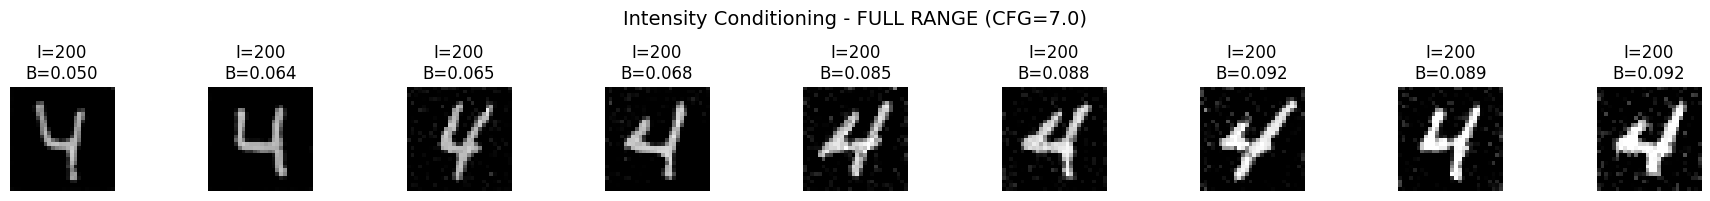

In [53]:
generate_intensity_samples_improved(
    labels= torch.ones(9)*4,
    thickness_vals=torch.linspace(1,4,9),
    intensity_vals=torch.ones(9)*200,
    sampling_model=sampling_model,
    rf=rf
)